# Baseline XGBoost

Modele XGBoost sur les features tabulaires (`lum_interieur_masque`, `lum_exterieur_masque`, `surface_masque`, `variance_laplacien`).
Meme pipeline que les autres baselines (SVM, KNN, Random Forest) : train / validation / test, GridSearch, evaluation.

Deux variantes :
1. **Baseline** : parametres XGBoost par defaut, sans ponderation.
2. **GridSearch (balanced)** : recherche d'hyperparametres + ponderation des classes via `sample_weight`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

## Chargement des donnees

In [2]:
# CSV de features versionnes dans le repo (dossier ../csv/).
# Adapter le chemin si vos features sont ailleurs.
chemin = "../csv/"
df_train = pd.read_csv(chemin + "train_features.csv", sep=",")
df_val   = pd.read_csv(chemin + "validation_features.csv", sep=",")
df_test  = pd.read_csv(chemin + "test_features.csv", sep=",")

X_train = df_train.drop(columns=["filename", "classe"]); y_train = df_train["classe"]
X_val   = df_val.drop(columns=["filename", "classe"]);   y_val   = df_val["classe"]
X_test  = df_test.drop(columns=["filename", "classe"]);  y_test  = df_test["classe"]

print("Dimensions :", X_train.shape, X_val.shape, X_test.shape)

Dimensions : (16668, 4) (2083, 4) (2084, 4)


## Encodage des labels

XGBoost attend des labels numeriques.

In [3]:
le = LabelEncoder()
y_train_e = le.fit_transform(y_train)
y_val_e   = le.transform(y_val)
y_test_e  = le.transform(y_test)
classes = list(le.classes_)
print("Classes :", classes)

Classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## Fonction d'evaluation

In [4]:
def evaluer(model, X, y_e, titre):
    """Affiche accuracy, f1_macro, classification_report et matrice de confusion."""
    y_pred = model.predict(X)
    acc = accuracy_score(y_e, y_pred)
    f1m = f1_score(y_e, y_pred, average="macro")

    print(f"===== {titre} =====")
    print(f"Accuracy : {acc:.4f}   |   f1_macro : {f1m:.2f}")
    print(classification_report(y_e, y_pred, target_names=classes, zero_division=0))

    cm = confusion_matrix(y_e, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, square=True, fmt="d", cmap="mako",
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f"Matrice de confusion - {titre}")
    plt.tight_layout()
    plt.show()
    return acc, f1m

## 1. Baseline (parametres par defaut, sans ponderation)

===== XGBoost baseline - Validation =====
Accuracy : 0.5987   |   f1_macro : 0.44
                 precision    recall  f1-score   support

          COVID       0.26      0.08      0.12       338
   Lung_Opacity       0.56      0.52      0.54       598
         Normal       0.65      0.86      0.74      1013
Viral Pneumonia       0.45      0.33      0.38       134

       accuracy                           0.60      2083
      macro avg       0.48      0.44      0.44      2083
   weighted avg       0.55      0.60      0.56      2083



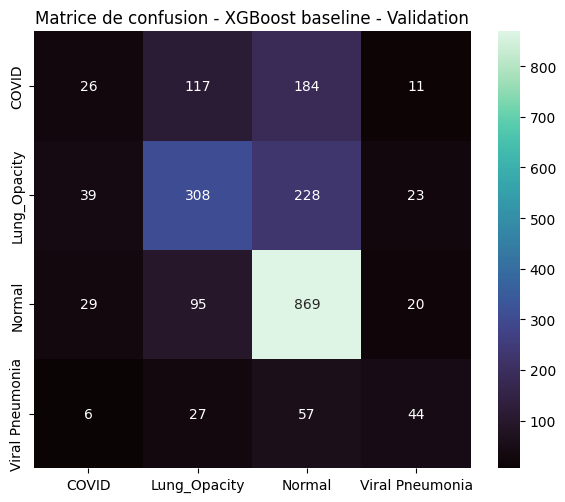

===== XGBoost baseline - Test =====
Accuracy : 0.5979   |   f1_macro : 0.47
                 precision    recall  f1-score   support

          COVID       0.38      0.12      0.18       337
   Lung_Opacity       0.55      0.53      0.54       599
         Normal       0.65      0.83      0.73      1014
Viral Pneumonia       0.50      0.38      0.43       134

       accuracy                           0.60      2084
      macro avg       0.52      0.46      0.47      2084
   weighted avg       0.56      0.60      0.56      2084



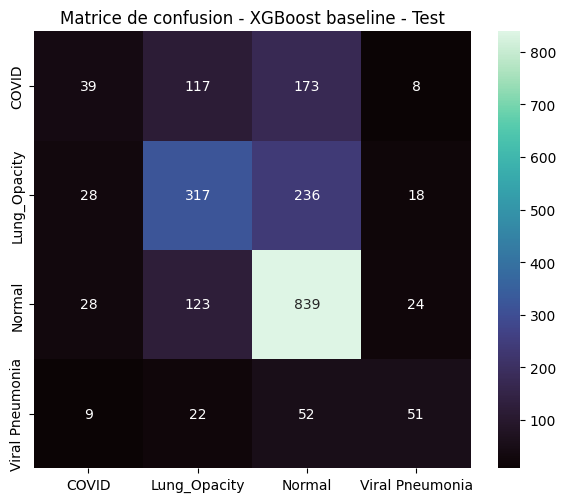

In [5]:
xgb_base = XGBClassifier(
    objective="multi:softmax", num_class=len(classes),
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
xgb_base.fit(X_train, y_train_e)

evaluer(xgb_base, X_val,  y_val_e,  "XGBoost baseline - Validation")
evaluer(xgb_base, X_test, y_test_e, "XGBoost baseline - Test");

## 2. GridSearch + ponderation des classes (balanced)

La ponderation `balanced` est passee via `sample_weight` (XGBoost n'a pas de `class_weight` natif en multiclasse).

In [6]:
sample_w = compute_sample_weight(class_weight="balanced", y=y_train_e)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}
xgb = XGBClassifier(
    objective="multi:softmax", num_class=len(classes),
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
grid = GridSearchCV(xgb, param_grid, scoring="f1_macro", cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train_e, sample_weight=sample_w)

print("Best params :", grid.best_params_)
print("Best CV f1_macro :", round(grid.best_score_, 4))

Fitting 3 folds for each of 24 candidates, totalling 72 fits


Best params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
Best CV f1_macro : 0.5061


===== XGBoost GridSearch balanced - Validation =====
Accuracy : 0.5319   |   f1_macro : 0.46
                 precision    recall  f1-score   support

          COVID       0.24      0.23      0.23       338
   Lung_Opacity       0.58      0.49      0.53       598
         Normal       0.71      0.63      0.67      1013
Viral Pneumonia       0.28      0.69      0.39       134

       accuracy                           0.53      2083
      macro avg       0.45      0.51      0.46      2083
   weighted avg       0.56      0.53      0.54      2083



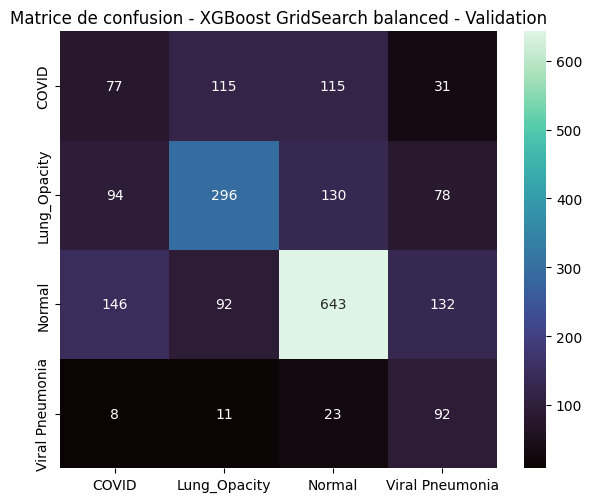

===== XGBoost GridSearch balanced - Test =====
Accuracy : 0.5398   |   f1_macro : 0.47
                 precision    recall  f1-score   support

          COVID       0.28      0.27      0.28       337
   Lung_Opacity       0.57      0.49      0.53       599
         Normal       0.72      0.63      0.67      1014
Viral Pneumonia       0.28      0.75      0.41       134

       accuracy                           0.54      2084
      macro avg       0.46      0.53      0.47      2084
   weighted avg       0.58      0.54      0.55      2084



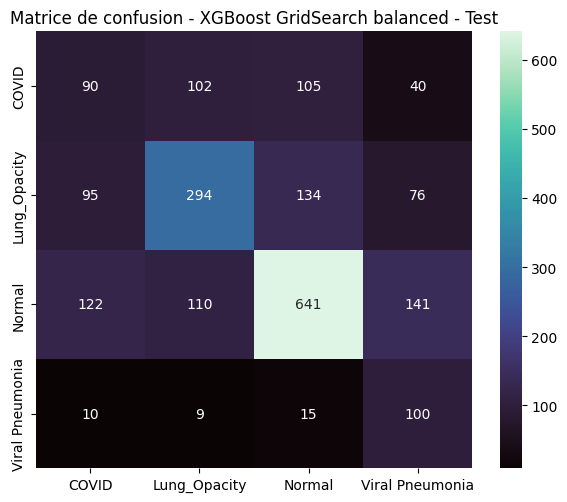

In [7]:
best = grid.best_estimator_
evaluer(best, X_val,  y_val_e,  "XGBoost GridSearch balanced - Validation")
evaluer(best, X_test, y_test_e, "XGBoost GridSearch balanced - Test");

## 3. Importance des features

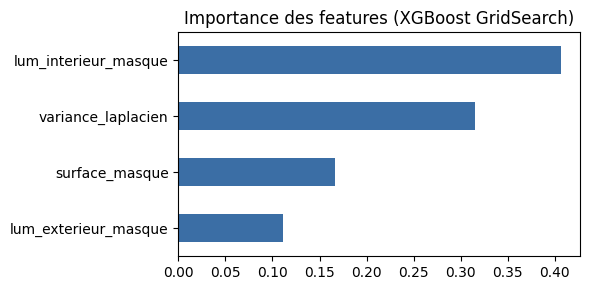

In [8]:
importances = pd.Series(best.feature_importances_, index=X_train.columns).sort_values()
importances.plot(kind="barh", figsize=(6, 3), color="#3b6ea5")
plt.title("Importance des features (XGBoost GridSearch)")
plt.tight_layout()
plt.show()

## Resultats reportes dans le tableau comparatif (`model_comparison`)

Metriques sur le **jeu de test** (coherent avec le SVM) :

| modele | accuracy | f1_macro | f1_covid | f1_normal | f1_lung_opacity | f1_viral_pneumonia |
|---|---|---|---|---|---|---|
| XGBoost (baseline, sans ponderation) | 0.5979 | 0.47 | 0.18 | 0.73 | 0.54 | 0.43 |
| XGBoost (GridSearch best, balanced) | 0.5398 | 0.47 | 0.28 | 0.67 | 0.53 | 0.41 |

Best params GridSearch : `n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8`.